In [1]:
import json
import os
import subprocess
from common import *
from experiment import NetworkSetting

# Collect Data

In [2]:
# Make the directory to store raw results
SIDEKICK_HOME = f'{os.environ["HOME"]}/sidekick-downloads'
RESULTS_DIR = f'{SIDEKICK_HOME}/data/media'
os.chdir(SIDEKICK_HOME)
os.system(f'mkdir -p {RESULTS_DIR}')
RESULTS_DIR

'/users/ygina/sidekick-downloads/data/media'

In [3]:
def create_command(label, duration, network_options=[], protocol_options=[]):
    """Create the command"""
    cmd = ['sudo', '-E', 'python3', 'emulation/main.py']
    cmd += ['--network-statistics', '--label', label] + network_options
    cmd += ['media']
    cmd += ['--duration', str(duration)] + protocol_options
    return cmd

def execute_command(cmd):
    """Run the command from the upper-level directory"""
    os.chdir(SIDEKICK_HOME)
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('WARNING: non-zero returncode', result.returncode)
        print(result.stderr)
    return result.stdout, result.stderr

In [4]:
def parse_raw_results(label, duration, network_options=[], protocol_options=[], execute=True, overwrite=False):
    filename = f'{RESULTS_DIR}/{label}.log'
    cmd = create_command(label, duration, network_options, protocol_options)
    if os.path.exists(filename) and not overwrite:
        with open(filename, 'r') as f:
            stdout = f.read()
    elif execute:
        print(filename, ' '.join(cmd))
        stdout, _ = execute_command(cmd)
        with open(filename, 'w') as f:
            f.write(stdout)
    else:
        print('MISSING:', filename, ' '.join(cmd))
        return
    result = json.loads(stdout)
    return result['outputs'][0]

In [5]:
base_network_options = lambda loss1: ['--bw1', '100', '--bw2', '10', '--delay1', '1', '--delay2', '25', '--loss1', str(loss1), '--loss2', '0']
results = {}
options = {
    'baseline': ([], []),
    'sniffing_quacker': (['--proxy', 'sidekick', '--quacker', '--threshold', '8', '--freq-pkts', '2'], []),
    'client_quacker': (['--proxy', 'sidekick', '--threshold', '8', '--freq-pkts', '2'], ['--client-quacker']),
}
labels = list(options.keys())

def set_result(label, duration, execute=True, overwrite=False):
    network_options, protocol_options = options[label]
    result = parse_raw_results(
        f'{label}_{duration}', duration, execute=execute, overwrite=overwrite,
        network_options=base_network_options('3.6') + network_options,
        protocol_options=protocol_options,
    )
    results[label] = result

In [6]:
set_result('baseline', 300)

In [7]:
set_result('sniffing_quacker', 300)

In [8]:
set_result('client_quacker', 300)

In [9]:
results.keys()

dict_keys(['baseline', 'sniffing_quacker', 'client_quacker'])

# Plot CDF Data

In [10]:
def preprocess_latencies(latencies, num_ticks=100):
    ticks = []
    latencies.sort()
    for i in range(num_ticks):
        index = int(i * len(latencies) / num_ticks)
        ticks.append(latencies[index])
    ticks.append(latencies[-1])
    # Convert ns to ms
    return [tick / 1000000.0 for tick in ticks]

In [11]:
def plot_delay_cdf(labels, results, title, min_pct=0, num_ticks=1000):
    plt.figure(figsize=(6, 4))
    for label in labels:
        data = results[label]
        data = preprocess_latencies(data, num_ticks=num_ticks)
        ys = [i / len(data) * 100.0 for i in range(len(data))]
        plt.plot(data, ys, label=label)
    plt.xlabel('De-Jitter Latency (ms)')
    plt.xticks()
    plt.xlim(0)

    plt.ylabel('Percentile')
    ticks = [tick for tick in range(min_pct, num_ticks + 1, 2)]
    plt.yticks(ticks=ticks, labels=[f'{tick}%' for tick in ticks])
    plt.yticks()
    plt.ylim(min_pct, 100.5)

    plt.grid()
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=2)
    plt.show()

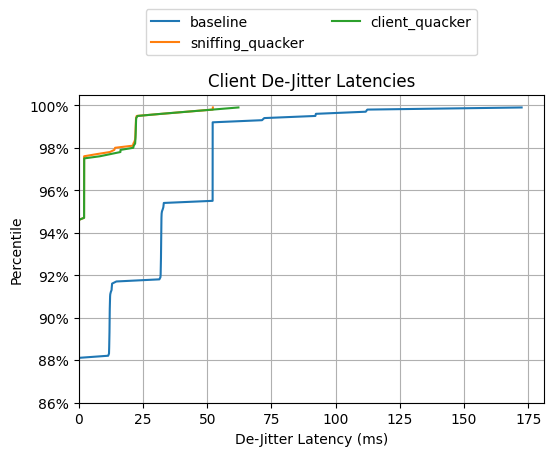

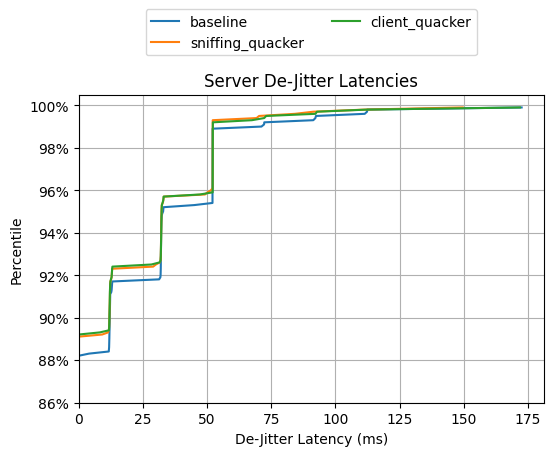

In [12]:
client_results = {}
server_results = {}
for label, result in results.items():
    client_results[label] = result.get('client_latencies')
    server_results[label] = result.get('server_latencies')
plot_delay_cdf(labels, client_results, min_pct=86, title='Client De-Jitter Latencies')
plot_delay_cdf(labels, server_results, min_pct=86, title='Server De-Jitter Latencies')

# Plot network statistics

In [13]:
def plot_network_statistic(labels, results, title='Number of Sent Packets', statistic='tx_packets'):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        ifaces = results[label]['statistics']['ifaces']
        data = results[label]['statistics'][statistic]
        assert len(data) == len(ifaces)
        x = np.arange(len(ifaces))
        plt.bar(x + i * width, data, width=width, label=label)

    plt.xlabel('Network Interface')
    plt.ylabel(statistic)
    plt.xticks(np.arange(len(ifaces)), ifaces)
    plt.ylim(0)

    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)
    plt.show()

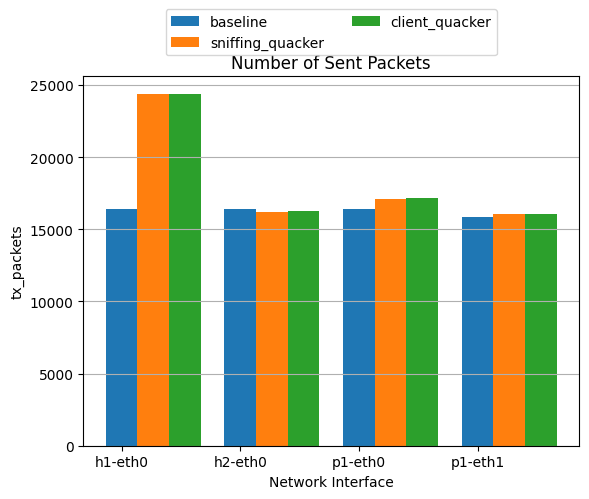

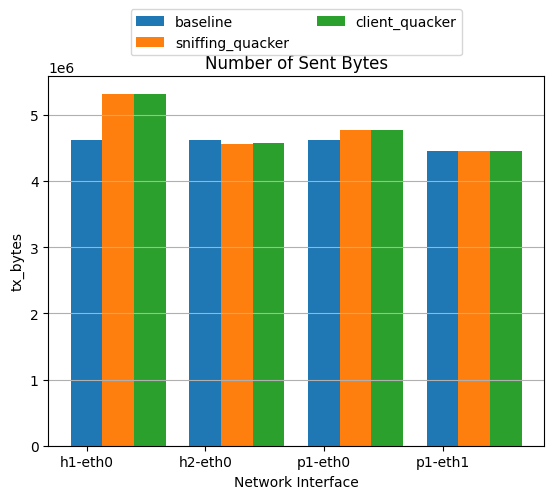

In [14]:
plot_network_statistic(labels, results, title='Number of Sent Packets', statistic='tx_packets')
plot_network_statistic(labels, results, title='Number of Sent Bytes', statistic='tx_bytes')